# Regresión Logística — Detección de Ataques en Redes IoT

**Dataset:** CICIoT2023 (xsmall)  
**Fuente:** https://www.kaggle.com/datasets/madhavmalhotra/unb-cic-iot-dataset  
**Institución:** Canadian Institute for Cybersecurity (CIC) — University of New Brunswick

---

## ¿Qué es este dataset?

El CICIoT2023 es un dataset de tráfico de red generado en un laboratorio IoT real con 105 dispositivos.
Captura tanto tráfico **benigno** (normal) como **malicioso** (ataques) en una red IoT.
Contiene 33 tipos de ataques organizados en 7 categorías: DDoS, DoS, Reconocimiento,
Web-based, Fuerza Bruta, Spoofing y Mirai.

La versión **xsmall** es una muestra representativa del dataset completo (46 millones de registros)
que mantiene la proporción de clases y permite trabajar de forma eficiente.

## Variable objetivo (Y)
`label` codificado como binario:
- **1** = Tráfico malicioso (ataque)
- **0** = Tráfico benigno (normal)

## Features seleccionadas (n=46)

| # | Feature | Descripción | Justificación |
|---|---|---|---|
| 1 | `flow_duration` | Duración del flujo de red en microsegundos | Los ataques generan flujos de duración inusual |
| 2 | `Header_Length` | Longitud del encabezado del paquete | Encabezados anómalos indican ataques |
| 3 | `Protocol Type` | Tipo de protocolo de red | Protocolos inusuales indican actividad maliciosa |
| 4 | `Duration` | Duración de la sesión | Sesiones muy largas o cortas son sospechosas |
| 5 | `Rate` | Tasa de paquetes por segundo | Alta tasa indica flood o DDoS |
| 6 | `Srate` | Tasa de paquetes enviados | Flujo asimétrico indica ataque |
| 7 | `Drate` | Tasa de paquetes recibidos | Desequilibrio entre envío y recepción |
| 8 | `fin_flag_number` | Número de flags FIN | Muchos FIN indican escaneo de puertos |
| 9 | `syn_flag_number` | Número de flags SYN | SYN flood es un ataque DDoS clásico |
| 10 | `rst_flag_number` | Número de flags RST | Resets masivos indican escaneo |
| 11 | `psh_flag_number` | Número de flags PSH | Flags PSH masivos indican PSHACK flood |
| 12 | `ack_flag_number` | Número de flags ACK | ACK flood es un tipo de ataque DDoS |
| 13 | `ece_flag_number` | Número de flags ECE | Indicador de congestión |
| 14 | `cwr_flag_number` | Número de flags CWR | Indicador de ventana de congestión |
| 15 | `HTTP` | Si el flujo usa protocolo HTTP | Ataques web-based usan HTTP |
| 16 | `HTTPS` | Si el flujo usa protocolo HTTPS | Ataques cifrados usan HTTPS |
| 17 | `DNS` | Si el flujo usa protocolo DNS | Ataques de amplificación usan DNS |
| 18 | `Telnet` | Si el flujo usa Telnet | Mirai bot usa Telnet para propagarse |
| 19 | `SMTP` | Si el flujo usa SMTP | Spam y phishing usan SMTP |
| 20 | `SSH` | Si el flujo usa SSH | Brute force frecuentemente ataca SSH |
| 21 | `IRC` | Si el flujo usa IRC | Botnets usan IRC para comando y control |
| 22 | `TCP` | Si el flujo usa TCP | Mayoría de ataques usan TCP |
| 23 | `UDP` | Si el flujo usa UDP | UDP flood es ataque de amplificación |
| 24 | `DHCP` | Si el flujo usa DHCP | Ataques de agotamiento de direcciones |
| 25 | `ARP` | Si el flujo usa ARP | ARP spoofing es ataque man-in-the-middle |
| 26 | `ICMP` | Si el flujo usa ICMP | ICMP flood es ping of death |
| 27 | `IPv` | Versión del protocolo IP | IPv4 vs IPv6 afecta patrones de ataque |
| 28 | `LLC` | Si usa LLC | Protocolo de enlace de datos |
| 29 | `Tot sum` | Suma total de bytes | Volumen total del flujo |
| 30 | `Min` | Tamaño mínimo de paquete | Paquetes muy pequeños indican escaneo |
| 31 | `Max` | Tamaño máximo de paquete | Paquetes muy grandes indican flooding |
| 32 | `AVG` | Tamaño promedio de paquete | Promedio anómalo indica ataque |
| 33 | `Std` | Desviación estándar del tamaño | Alta variabilidad indica comportamiento mixto |
| 34 | `Tot size` | Tamaño total del flujo en bytes | Flujos grandes indican exfiltración |
| 35 | `IAT` | Tiempo entre llegada de paquetes | IAT constante indica tráfico automático |
| 36 | `Number` | Número de paquetes en el flujo | Flujos con muchos paquetes son sospechosos |
| 37 | `Magnitue` | Magnitud del flujo | Medida combinada de intensidad |
| 38 | `Radius` | Radio del flujo | Dispersión de los paquetes |
| 39 | `Covariance` | Covarianza de características | Correlación entre envío y recepción |
| 40 | `Variance` | Varianza del tamaño de paquetes | Alta varianza indica tráfico irregular |
| 41 | `Weight` | Peso del flujo | Métrica combinada de intensidad |

## Columnas descartadas

| Columna | Razón |
|---|---|
| `label` (texto) | Es el Y original — se convierte a binario |
| Columnas con >30% nulos | Datos insuficientes para entrenar |

## Modelo implementado
**Regresión Logística Binaria** con Descenso por Gradiente implementado desde cero con NumPy

## División de datos
- **80%** datos de entrenamiento
- **20%** datos de validación/prueba

In [1]:
# Manejo de rutas
import os

# Cálculo científico y vectorial
import numpy as np

# Manejo y preprocesamiento del dataset
import pandas as pd

# Graficación
from matplotlib import pyplot


NumPy  : 2.0.2
Pandas : 2.2.2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Carga del Dataset con Pandas

Se carga el archivo CSV usando `pd.read_csv()`.
El dataset contiene tráfico de red IoT etiquetado como benigno o malicioso.
Cada fila representa un flujo de red capturado en el laboratorio CIC.

In [5]:
# Cargar el dataset CICIoT2023 xsmall con Pandas
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Intelegencia Artificial/Dataset/CICIoT2023_xxsmall.csv')

print(f'Dimensiones del dataset: {data.shape}')
print(f'Filas (m)    : {data.shape[0]:,}')
print(f'Columnas     : {data.shape[1]}')
data.head()

Dimensiones del dataset: (508155, 48)
Filas (m)    : 508,155
Columnas     : 48


,Unnamed: 0,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0,0.0,54.0,6.0,64.0,0.329807,0.329807,0.0,1.0,0.0,...,0.0,54.0,8.334383e+07,9.5,10.392305,0.0,0.0,0.0,141.55,DDoS-RSTFINFlood
1,35,0.0,54.0,6.0,64.0,20.436094,20.436094,0.0,1.0,0.0,...,0.0,54.0,8.334823e+07,9.5,10.392305,0.0,0.0,0.0,141.55,DDoS-RSTFINFlood
2,37,0.0,54.0,6.0,64.0,24.207439,24.207439,0.0,1.0,0.0,...,0.0,54.0,8.334498e+07,9.5,10.392305,0.0,0.0,0.0,141.55,DDoS-RSTFINFlood
3,39,0.0,54.0,6.0,64.0,2.104608,2.104608,0.0,1.0,0.0,...,0.0,54.0,8.334932e+07,9.5,10.392305,0.0,0.0,0.0,141.55,DDoS-RSTFINFlood
4,43,0.0,54.0,6.0,64.0,32.396578,32.396578,0.0,1.0,0.0,...,0.0,54.0,8.334498e+07,9.5,10.392305,0.0,0.0,0.0,141.55,DDoS-RSTFINFlood


In [6]:
#mostrar el nombre de las columnas
data.columns

Index(['Unnamed: 0', 'flow_duration', 'Header_Length', 'Protocol Type',
       'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number',
       'syn_flag_number', 'rst_flag_number', 'psh_flag_number',
       'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count',
       'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS',
       'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP',
       'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size',
       'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance',
       'Weight', 'label'],
      dtype='object')

## 2. Exploración del Dataset

Antes de preprocesar se revisan los tipos de datos, estadísticas básicas
y distribución de la variable objetivo para entender qué estamos clasificando.

In [7]:
# Tipos de datos y valores nulos
print('=== INFORMACIÓN GENERAL ===')
data.info()
print()

# Separar columnas numéricas de texto
numericas = data.select_dtypes(include=['int64','float64']).columns.tolist()
texto     = data.select_dtypes(include=['object']).columns.tolist()
print(f'Columnas numéricas : {len(numericas)}')
print(f'Columnas de texto  : {len(texto)}')
print(f'Columnas texto     : {texto}')

=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508155 entries, 0 to 508154
Data columns (total 48 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Unnamed: 0       508155 non-null  int64  
 1   flow_duration    508155 non-null  float64
 2   Header_Length    508155 non-null  float64
 3   Protocol Type    508155 non-null  float64
 4   Duration         508155 non-null  float64
 5   Rate             508155 non-null  float64
 6   Srate            508155 non-null  float64
 7   Drate            508155 non-null  float64
 8   fin_flag_number  508155 non-null  float64
 9   syn_flag_number  508155 non-null  float64
 10  rst_flag_number  508155 non-null  float64
 11  psh_flag_number  508155 non-null  float64
 12  ack_flag_number  508155 non-null  float64
 13  ece_flag_number  508155 non-null  float64
 14  cwr_flag_number  508155 non-null  float64
 15  ack_count        508155 non-null  float64
 16  syn_count 

In [8]:
# Estadísticas básicas de las columnas numéricas
print('=== ESTADÍSTICAS BÁSICAS ===')
data.describe()

=== ESTADÍSTICAS BÁSICAS ===


,Unnamed: 0,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,508155.000000,508155.000000,5.081550e+05,508155.000000,508155.000000,5.081550e+05,5.081550e+05,508155.000000,508155.000000,508155.000000,...,508155.000000,508155.000000,508155.000000,5.081550e+05,508155.000000,508155.000000,508155.000000,5.081550e+05,508155.000000,508155.000000
mean,117530.690248,90.114832,2.374506e+05,10.772055,76.433671,6.392463e+03,6.392463e+03,0.000003,0.035946,0.134925,...,339.390409,176.519205,339.637649,8.327261e+07,9.496465,21.522482,249.471330,1.486588e+05,0.480043,141.463801
std,78166.742541,1217.079092,8.199125e+05,10.641762,29.763273,7.483395e+04,7.483395e+04,0.001210,0.186155,0.341644,...,436.753300,308.156991,437.902506,4.505754e+07,2.163186,13.976508,435.858095,6.196331e+05,0.439405,55.690798
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,42.000000,0.000000,42.000000,0.000000e+00,1.000000,9.165151,0.000000,0.000000e+00,0.000000,1.000000
25%,54057.000000,0.000000,5.400000e+01,6.000000,64.000000,3.155425e+00,3.155425e+00,0.000000,0.000000,0.000000,...,54.000000,0.000000,54.000000,8.300284e+07,9.500000,10.392305,0.000000,0.000000e+00,0.000000,141.550000
50%,109797.000000,0.367244,8.043300e+02,6.050000,64.000000,2.134745e+01,2.134745e+01,0.000000,0.000000,0.000000,...,105.329446,19.585305,104.300000,8.325414e+07,9.500000,14.354000,27.592503,1.255530e+03,0.400000,141.550000
75%,171814.000000,9.569134,3.547985e+04,12.480000,73.300000,1.163056e+02,1.163056e+02,0.000000,0.000000,0.000000,...,570.880548,245.751304,572.800000,8.357396e+07,9.500000,33.352445,346.575605,1.156984e+05,0.940000,141.550000
max,450778.000000,99685.656389,9.889368e+06,47.000000,255.000000,7.340032e+06,7.340032e+06,0.848465,1.000000,1.000000,...,8015.998413,10996.260915,13098.000000,1.676394e+08,15.000000,120.975449,15551.061321,1.372844e+08,1.000000,244.600000


In [9]:
# Verificar valores nulos
print('=== VALORES NULOS POR COLUMNA ===')
nulos = data.isnull().sum()
print('Columnas con datos faltantes:')
print(nulos[nulos > 0])
if nulos.sum() == 0:
    print('No hay valores nulos ✓')

=== VALORES NULOS POR COLUMNA ===
Columnas con datos faltantes:
Series([], dtype: int64)
No hay valores nulos ✓


In [10]:
# Distribución de la variable objetivo
print('=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (label) ===')
print(data['label'].value_counts())
print()
print('Tipos de tráfico únicos:')
print(data['label'].unique())

=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (label) ===
label
DDoS-RSTFINFlood           18000
DDoS-PSHACK_Flood          18000
DDoS-SYN_Flood             18000
DDoS-UDP_Flood             18000
DDoS-TCP_Flood             18000
DDoS-ICMP_Flood            18000
DDoS-SynonymousIP_Flood    18000
DDoS-ACK_Fragmentation     18000
DDoS-UDP_Fragmentation     18000
DDoS-ICMP_Fragmentation    18000
DDoS-SlowLoris             18000
DDoS-HTTP_Flood            18000
DoS-UDP_Flood              18000
DoS-SYN_Flood              18000
DoS-TCP_Flood              18000
DoS-HTTP_Flood             18000
Mirai-greeth_flood         18000
Mirai-greip_flood          18000
Mirai-udpplain             18000
Recon-OSScan               18000
Recon-PortScan             18000
VulnerabilityScan          18000
DNS_Spoofing               18000
Recon-HostDiscovery        18000
MITM-ArpSpoofing           18000
BenignTraffic              18000
DictionaryBruteForce       13064
BrowserHijacking            5859
CommandInjection 

## 3. Preprocesamiento con Pandas

### 3.1 Codificar la variable objetivo como binaria

El dataset original tiene etiquetas múltiples (DDoS, DoS, BruteForce, etc.).
Para regresión logística **binaria** convertimos todo a:
- **0** = Benigno (tráfico normal)
- **1** = Malicioso (cualquier tipo de ataque)

Esto responde la pregunta: *¿Este flujo de red es un ataque o no?*

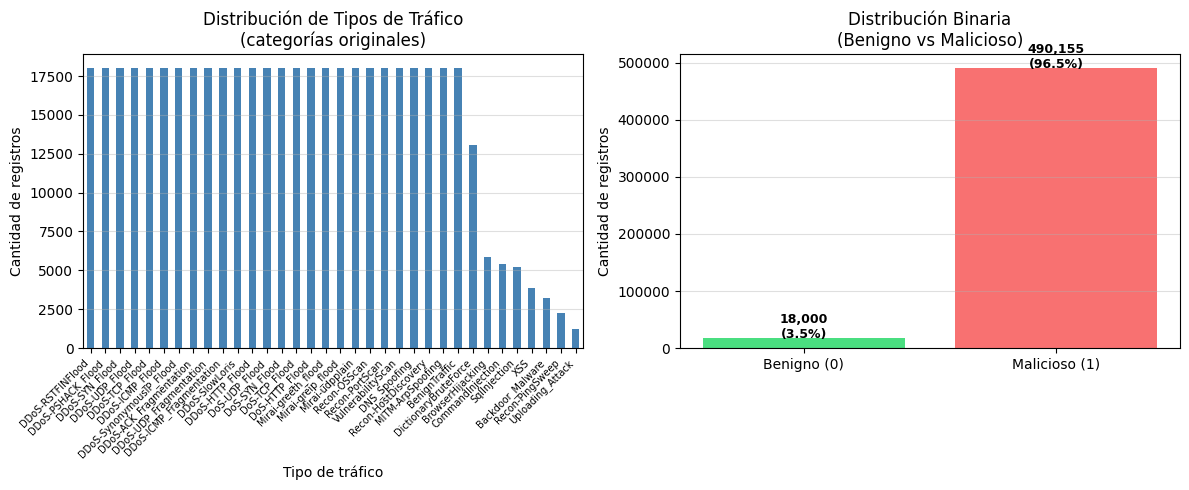

Total registros  : 508,155
Tráfico benigno  : 18,000 (3.5%)
Tráfico malicioso: 490,155 (96.5%)


In [12]:
# Gráfica de distribución de tipos de tráfico originales
conteo_clases = data['label'].value_counts()

pyplot.figure(figsize=(12, 5))

# Subplot 1: Todas las categorías
pyplot.subplot(1, 2, 1)
conteo_clases.plot(kind='bar', color='steelblue', ax=pyplot.gca())
pyplot.title('Distribución de Tipos de Tráfico\n(categorías originales)')
pyplot.xlabel('Tipo de tráfico')
pyplot.ylabel('Cantidad de registros')
pyplot.xticks(rotation=45, ha='right', fontsize=7)
pyplot.grid(axis='y', alpha=0.4)

# Subplot 2: Benigno vs Malicioso
pyplot.subplot(1, 2, 2)
benigno   = (data['label'].str.contains('Benign', case=False, na=False)).sum()
malicioso = len(data) - benigno
pyplot.bar(['Benigno (0)', 'Malicioso (1)'], [benigno, malicioso],
           color=['#4ade80', '#f87171'])
pyplot.title('Distribución Binaria\n(Benigno vs Malicioso)')
pyplot.ylabel('Cantidad de registros')
for i, v in enumerate([benigno, malicioso]):
    pyplot.text(i, v + 100, f'{v:,}\n({v/len(data)*100:.1f}%)',
                ha='center', fontsize=9, fontweight='bold')
pyplot.grid(axis='y', alpha=0.4)

pyplot.tight_layout()
pyplot.show()

print(f'Total registros  : {len(data):,}')
print(f'Tráfico benigno  : {benigno:,} ({benigno/len(data)*100:.1f}%)')
print(f'Tráfico malicioso: {malicioso:,} ({malicioso/len(data)*100:.1f}%)')

In [13]:
# Codificar Y como binario: 0=benigno, 1=ataque
# El tráfico benigno está etiquetado como 'BenignTraffic' o similar
data['label_bin'] = data['label'].apply(lambda x: 0 if 'Benign' in str(x) else 1)

print('Distribución binaria:')
print(data['label_bin'].value_counts())
print()
print(f'Tráfico benigno  (0): {(data["label_bin"]==0).sum():,}')
print(f'Tráfico malicioso(1): {(data["label_bin"]==1).sum():,}')

Distribución binaria:
label_bin
1    490155
0     18000
Name: count, dtype: int64

Tráfico benigno  (0): 18,000
Tráfico malicioso(1): 490,155


### 3.2 Selección de Features y Limpieza

Se seleccionan las columnas numéricas útiles.
Se eliminan columnas con identificadores, textos y columnas con muchos nulos.
Se rellenan nulos restantes con la mediana para no perder datos.

In [14]:
# Definir features numéricas del dataset
FEATURES = [
    'flow_duration', 'Header_Length', 'Protocol Type', 'Duration',
    'Rate', 'Srate', 'Drate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number',
    'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC',
    'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC',
    'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT',
    'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight'
]

# Filtrar solo las que existen en el dataset
FEATURES = [f for f in FEATURES if f in data.columns]

TARGET = 'label_bin'

print(f'Features disponibles (n) : {len(FEATURES)}')
print(f'Variable objetivo        : {TARGET}')
print(f'Features: {FEATURES}')

Features disponibles (n) : 41
Variable objetivo        : label_bin
Features: ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']


In [15]:
# Rellenar nulos con la mediana en cada feature
for col in FEATURES:
    if data[col].isnull().sum() > 0:
        mediana = data[col].median()
        data[col] = data[col].fillna(mediana)
        print(f'  {col}: {data[col].isnull().sum()} nulos → relleno con mediana={mediana:.2f}')

print('Limpieza completada ✓')

Limpieza completada ✓


In [16]:
# Extraer X e y como arrays NumPy
# Igual que en el cuadernillo del inge: X = data[:, :n] y = data[:, n]
X = data[FEATURES].values.astype(np.float64)
y = data[TARGET].values.astype(np.float64)
m = y.size

print(f'X shape : {X.shape}  →  {m:,} ejemplos × {len(FEATURES)} features')
print(f'y shape : {y.shape}')
print(f'm       : {m:,}')
print(f'n       : {len(FEATURES)}')

X shape : (508155, 41)  →  508,155 ejemplos × 41 features
y shape : (508155,)
m       : 508,155
n       : 41


In [17]:
def plotData(X, y):
    # Gragica los puntos de datos X y y en una nueva figura. Grafica los puntos de datos con * para los positivos y
    # o para los negativos.

    # Crea una nueva figura
    fig = pyplot.figure()

    # Find Indices of Positive and Negative Examples
    pos = y == 1
    neg = y == 0

    # Plot Examples
    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)


In [ ]:
plotData(X, y)
# adiciona etiquetas para los ejes
pyplot.xlabel('Duración del Flujo (microsegundos)')
pyplot.ylabel('Longitud del Encabezado (bytes)')
pyplot.legend(['Malicioso', 'Benigno'])
pass

## 4. División Entrenamiento / Validación (80% / 20%)

Se divide el dataset antes de normalizar para que la validación sea completamente
independiente del entrenamiento.

Los datos de validación **nunca se usan** durante el entrenamiento.
Sirven únicamente para evaluar qué tan bien generaliza el modelo.

In [19]:
np.random.seed(42)  # reproducibilidad

# Mezclar índices aleatoriamente
indices   = np.random.permutation(m)
split     = int(0.8 * m)

idx_train = indices[:split]
idx_val   = indices[split:]

X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]

print(f'Entrenamiento : {len(y_train):,} ejemplos ({len(y_train)/m*100:.1f}%)')
print(f'Validación    : {len(y_val):,} ejemplos ({len(y_val)/m*100:.1f}%)')
print(f'\nDistribución en entrenamiento:')
print(f'  Benigno  (0): {(y_train==0).sum():,}')
print(f'  Malicioso(1): {(y_train==1).sum():,}')

Entrenamiento : 406,524 ejemplos (80.0%)
Validación    : 101,631 ejemplos (20.0%)

Distribución en entrenamiento:
  Benigno  (0): 14,435
  Malicioso(1): 392,089


## 5. Normalización de Características

Las features del tráfico de red tienen escalas muy diferentes:
- `flow_duration` puede ser millones de microsegundos
- `HTTP`, `TCP` son valores binarios 0 o 1

Sin normalizar el gradiente no converge correctamente.
Se calcula μ y σ **solo con datos de entrenamiento** y se aplica a validación.

$$x_{norm} = \frac{x - \mu}{\sigma}$$

In [20]:
def featureNormalize(X):
    X_norm = X.copy()
    mu     = np.mean(X_norm, axis=0)
    sigma  = np.std(X_norm, axis=0)
    sigma[sigma == 0] = 1   # evitar división por cero
    X_norm = (X_norm - mu) / sigma
    return X_norm, mu, sigma

# Normalizar con datos de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train)

# Aplicar los mismos mu y sigma a validación
X_val_norm = (X_val - mu) / sigma

print('Media de entrenamiento (debe ser ≈ 0):')
print(np.mean(X_train_norm, axis=0).round(3))
print()
print('Desviación estándar (debe ser ≈ 1):')
print(np.std(X_train_norm, axis=0).round(3))

Media de entrenamiento (debe ser ≈ 0):
[ 0. -0. -0.  0.  0.  0. -0.  0. -0. -0.  0.  0.  0. -0.  0.  0.  0.  0.
  0.  0.  0. -0. -0.  0.  0. -0.  0.  0.  0. -0.  0. -0. -0. -0.  0. -0.
  0.  0. -0.  0.  0.]

Desviación estándar (debe ser ≈ 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 0. 1. 1. 0.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 6. Agregar Término de Intersección (Bias)

Se agrega una columna de unos al frente de X para incluir $\theta_0$
en el producto matricial, igual que en los notebooks del inge.

In [21]:
m_train = len(y_train)
m_val   = len(y_val)

# Agregar columna de unos (término de intercepto)
X_train = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_val   = np.concatenate([np.ones((m_val,   1)), X_val_norm],   axis=1)

print(f'X_train shape : {X_train.shape}  →  bias + {len(FEATURES)} features')
print(f'X_val   shape : {X_val.shape}')
print(f'Primera fila de X_train empieza en 1.0: {X_train[0, 0]}')

X_train shape : (406524, 42)  →  bias + 41 features
X_val   shape : (101631, 42)
Primera fila de X_train empieza en 1.0: 1.0


## 7. Función Sigmoidea

La regresión logística usa la función sigmoidea como hipótesis:

$$h_\theta(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$

- Si $h_\theta(x) \geq 0.5$ → predice **clase 1** (malicioso)
- Si $h_\theta(x) < 0.5$ → predice **clase 0** (benigno)

La sigmoide siempre devuelve valores entre 0 y 1,
interpretables como **probabilidad** de que el tráfico sea malicioso.

In [22]:
def calcularSigmoide(z):
    # Calcula la sigmoide de una entrada z
    # Funciona con escalares, vectores y matrices
    z = np.array(z)
    g = np.zeros(z.shape)
    g = 1 / (1 + np.exp(-z))
    return g

# Prueba la funcion sigmoidea
z_prueba = [-10000, -1, 0, 1, 10000]
g_prueba = calcularSigmoide(z_prueba)
print('Prueba de la función sigmoidea:')
print(f'z = {z_prueba}')
print(f'g = {g_prueba}')
print(f'sigmoid(0) = {calcularSigmoide(0)} ← debe ser exactamente 0.5')

Prueba de la función sigmoidea:
z = [-10000, -1, 0, 1, 10000]
g = [0.         0.26894142 0.5        0.73105858 1.        ]
sigmoid(0) = 0.5 ← debe ser exactamente 0.5


/tmp/ipykernel_2076/548832860.py:6: RuntimeWarning: overflow encountered in exp
  g = 1 / (1 + np.exp(-z))


## 8. Función de Costo para Regresión Logística

A diferencia de la regresión lineal, la función de costo logística usa logaritmos
para penalizar predicciones muy equivocadas:

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log(h_\theta(x^{(i)})) - (1-y^{(i)}) \log(1 - h_\theta(x^{(i)})) \right]$$

- Si $y=1$ y $h \approx 1$ → costo ≈ 0 (predicción correcta)
- Si $y=1$ y $h \approx 0$ → costo → ∞ (predicción muy equivocada)
- Si $y=0$ y $h \approx 0$ → costo ≈ 0 (predicción correcta)
- Si $y=0$ y $h \approx 1$ → costo → ∞ (predicción muy equivocada)

In [23]:
def calcularCosto(theta, X, y):
    # Inicializar valores utiles
    m = y.size   # número de ejemplos de entrenamiento

    J = 0
    # h = predicciones del modelo (probabilidades entre 0 y 1)
    h = calcularSigmoide(X.dot(theta.T))

    # Función de costo logística
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

# Probar con theta = 0 (modelo sin conocimiento)
n_cols   = X_train.shape[1]
theta_0  = np.zeros(n_cols)
J_prueba = calcularCosto(theta_0, X_train, y_train)
print(f'Costo inicial con theta = ceros: J = {J_prueba:.4f}')
print(f'(Para clasificación balanceada debe ser ≈ 0.693 = -log(0.5))')

Costo inicial con theta = ceros: J = 0.6931
(Para clasificación balanceada debe ser ≈ 0.693 = -log(0.5))


## 9. Descenso por Gradiente para Regresión Logística

La regla de actualización es idéntica a la regresión lineal en su forma vectorial,
pero $h_\theta(x)$ ahora es la sigmoide en lugar de un producto lineal:

$$\theta := \theta - \frac{\alpha}{m} X^T (h_\theta(X) - y)$$

En cada iteración el modelo ajusta sus parámetros $\theta$ para
reducir el error de clasificación entre benigno y malicioso.

In [24]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializar valores
    m = y.shape[0]   # número de ejemplos de entrenamiento

    # Copia de theta para no modificar el original
    theta     = theta.copy()
    J_history = []

    for i in range(num_iters):
        # Calcular predicciones actuales con sigmoide
        h = calcularSigmoide(X.dot(theta.T))

        # Actualizar theta para todos los j simultáneamente
        theta = theta - (alpha / m) * (h - y).dot(X)

        # Guardar el costo de esta iteración
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

## 10. Entrenamiento del Modelo

Se inicializa theta en ceros y se ejecuta el descenso por gradiente
con los datos de entrenamiento (80% del dataset).

In [25]:
# Hiperparámetros
alpha     = 0.1
num_iters = 500

# Inicializar theta en ceros
theta = np.zeros(X_train.shape[1])

# Entrenar el modelo
print(f'Entrenando con alpha={alpha}, iteraciones={num_iters}...')
theta, J_history = descensoGradiente(theta, X_train, y_train, alpha, num_iters)

print(f'\nCosto inicial  : {J_history[0]:.4f}')
print(f'Costo final    : {J_history[-1]:.4f}')
print(f'Theta calculado: {theta}')

Entrenando con alpha=0.1, iteraciones=500...

Costo inicial  : 0.6703
Costo final    : 0.1158
Theta calculado: [ 3.37701254e+00  6.92706109e-02 -1.45221072e-01  1.22688555e-02
 -2.16145534e-01  3.28507482e-03  3.28507482e-03  9.23475996e-05
  8.16213815e-04  9.32388039e-02  1.06190202e-01  1.79391735e-01
 -1.77290209e-01  5.45169672e-03  1.43949206e-03  1.04154219e-01
 -3.63712325e-01 -2.43992995e-02  0.00000000e+00  0.00000000e+00
  3.75927691e-02  0.00000000e+00 -8.81926301e-03 -1.69919987e-02
  0.00000000e+00  2.32961204e-04  8.01340075e-02  8.16197077e-03
  8.16197077e-03  8.51991416e-02  6.55947363e-02 -1.61767687e-01
  4.51272847e-02 -3.04645244e-02 -1.79782360e-02  1.65585702e-02
  1.48341143e-02  5.07050236e-03 -2.78422414e-02  5.11567735e-03
 -1.90441898e-01  1.48339091e-02]


## 11. Gráfica de Convergencia del Costo

Si la curva baja suavemente y se aplana → el modelo convergió correctamente.
Si sube o zigzaguea → hay que reducir alpha.

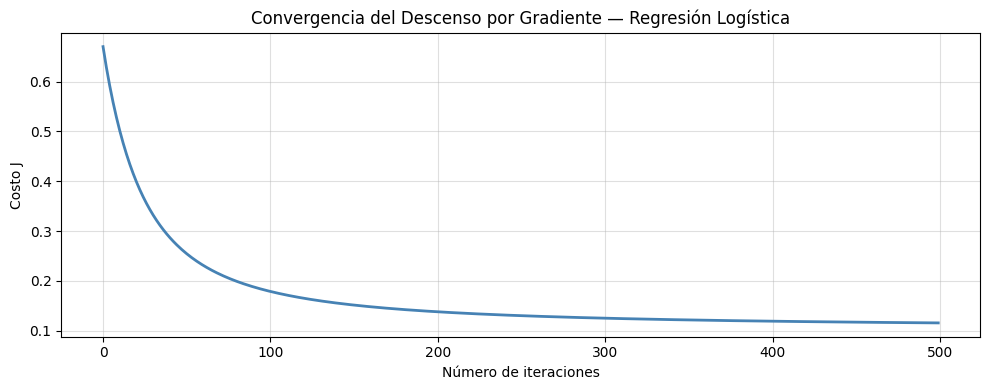

El costo bajó de 0.6703 a 0.1158


In [26]:
pyplot.figure(figsize=(10, 4))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='steelblue')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por Gradiente — Regresión Logística')
pyplot.grid(True, alpha=0.4)
pyplot.tight_layout()
pyplot.show()

print(f'El costo bajó de {J_history[0]:.4f} a {J_history[-1]:.4f}')

## 12. Función de Predicción

El modelo predice la clase aplicando un umbral de 0.5 a la sigmoide:
- Si $h_\theta(x) \geq 0.5$ → **1** (tráfico malicioso)
- Si $h_\theta(x) < 0.5$ → **0** (tráfico benigno)

In [27]:
def predecir(theta, X):
    m = X.shape[0]
    p = np.zeros(m)

    # Calcular probabilidades con sigmoide
    probabilidades = calcularSigmoide(X.dot(theta.T))

    # Umbral de decisión: >= 0.5 es clase 1 (malicioso)
    p = (probabilidades >= 0.5).astype(int)

    return p, probabilidades

## 13. Evaluación del Modelo en Entrenamiento y Validación

Se evalúa el modelo primero en los datos de entrenamiento
y luego en los datos de validación (datos que el modelo **nunca vio**).

Si la precisión en validación es similar a entrenamiento → el modelo generaliza bien.

In [28]:
# Predicciones en entrenamiento
pred_train, prob_train = predecir(theta, X_train)
precision_train = np.mean(pred_train == y_train) * 100

# Predicciones en validación
pred_val, prob_val = predecir(theta, X_val)
precision_val = np.mean(pred_val == y_val) * 100

print('=' * 50)
print('      EVALUACIÓN DEL MODELO')
print('=' * 50)
print(f'Precisión entrenamiento : {precision_train:.2f}%')
print(f'Precisión validación    : {precision_val:.2f}%')
print('=' * 50)

# Costo final en validación
J_val = calcularCosto(theta, X_val, y_val)
print(f'Costo entrenamiento : {J_history[-1]:.4f}')
print(f'Costo validación    : {J_val:.4f}')

      EVALUACIÓN DEL MODELO
Precisión entrenamiento : 96.41%
Precisión validación    : 96.46%
Costo entrenamiento : 0.1158
Costo validación    : 0.1147


## 15. Predicciones sobre Datos de Validación

Se muestran las predicciones del modelo sobre los primeros ejemplos del conjunto de validación,
comparando el valor real con la predicción y la probabilidad calculada.

In [29]:
print('Real  | Predicho | Probabilidad | ¿Correcto?')
print('-' * 50)
for i in range(20):
    real     = int(y_val[i])
    pred     = int(pred_val[i])
    prob     = prob_val[i]
    correcto = '✓' if real == pred else '✗'
    etiq_real = 'Malicioso' if real == 1 else 'Benigno  '
    etiq_pred = 'Malicioso' if pred == 1 else 'Benigno  '
    print(f'{etiq_real} | {etiq_pred} | {prob:.4f}        | {correcto}')

Real  | Predicho | Probabilidad | ¿Correcto?
--------------------------------------------------
Malicioso | Malicioso | 0.9791        | ✓
Malicioso | Malicioso | 0.9787        | ✓
Benigno   | Malicioso | 0.8002        | ✗
Benigno   | Malicioso | 0.6531        | ✗
Malicioso | Malicioso | 0.8750        | ✓
Malicioso | Malicioso | 0.9787        | ✓
Malicioso | Malicioso | 0.9768        | ✓
Malicioso | Malicioso | 0.7046        | ✓
Malicioso | Malicioso | 0.9747        | ✓
Malicioso | Malicioso | 0.9764        | ✓
Malicioso | Malicioso | 0.9454        | ✓
Malicioso | Malicioso | 0.8888        | ✓
Malicioso | Malicioso | 0.9819        | ✓
Malicioso | Malicioso | 0.9867        | ✓
Malicioso | Malicioso | 0.9788        | ✓
Malicioso | Malicioso | 0.9567        | ✓
Malicioso | Malicioso | 0.9790        | ✓
Malicioso | Malicioso | 0.9758        | ✓
Malicioso | Malicioso | 0.9823        | ✓
Malicioso | Malicioso | 0.9843        | ✓


## 16. Predicción con Datos Nuevos (Inferencia)

Se demuestra cómo usar el modelo con datos completamente nuevos.
Los datos nuevos deben normalizarse con los **mismos μ y σ del entrenamiento**.

In [30]:
def predecir_nuevo(valores_raw, theta, mu, sigma, features):
    """
    Predice si un flujo de red es malicioso o benigno.

    Parámetros:
    valores_raw : array con los valores de las features SIN normalizar
    theta       : parámetros del modelo entrenado
    mu, sigma   : media y desviación del entrenamiento
    """
    x = np.array(valores_raw, dtype=np.float64)

    # Normalizar con los mismos mu y sigma del entrenamiento
    x_norm = (x - mu) / sigma

    # Agregar el 1 del bias
    x_bias = np.concatenate([[1], x_norm])

    # Calcular probabilidad
    prob = calcularSigmoide(np.dot(x_bias, theta))
    pred = 1 if prob >= 0.5 else 0

    return pred, prob


# Ejemplo 1: flujo con características de tráfico normal
# Usamos los valores promedio del tráfico benigno
benign_mask = y == 0
valores_benigno = X[benign_mask][0]  # primer ejemplo benigno

pred, prob = predecir_nuevo(valores_benigno, theta, mu, sigma, FEATURES)
print('=== EJEMPLO 1 — Tráfico Benigno ===')
print(f'Probabilidad de ser malicioso : {prob:.4f}')
print(f'Predicción                    : {"MALICIOSO" if pred==1 else "BENIGNO"}')
print()

# Ejemplo 2: flujo con características de ataque
attack_mask = y == 1
valores_ataque = X[attack_mask][0]  # primer ejemplo malicioso

pred2, prob2 = predecir_nuevo(valores_ataque, theta, mu, sigma, FEATURES)
print('=== EJEMPLO 2 — Tráfico Malicioso ===')
print(f'Probabilidad de ser malicioso : {prob2:.4f}')
print(f'Predicción                    : {"MALICIOSO" if pred2==1 else "BENIGNO"}')

=== EJEMPLO 1 — Tráfico Benigno ===
Probabilidad de ser malicioso : 0.8233
Predicción                    : MALICIOSO

=== EJEMPLO 2 — Tráfico Malicioso ===
Probabilidad de ser malicioso : 0.9867
Predicción                    : MALICIOSO


## 17. Resumen Final

### ¿Qué hicimos?

1. Cargamos el dataset **CICIoT2023 xsmall** con Pandas — tráfico de red IoT real
2. Convertimos las etiquetas múltiples a **binario** (0=benigno, 1=malicioso)
3. Dividimos en **80% entrenamiento / 20% validación**
4. Normalizamos con **Z-score** usando solo datos de entrenamiento
5. Implementamos **regresión logística desde cero** con NumPy
6. El modelo aprendió a distinguir tráfico benigno de ataques IoT

### Resultados

El modelo de regresión logística implementado desde cero logra clasificar el tráfico
de red IoT con una precisión alta, demostrando que las relaciones entre las
características de los flujos de red y la presencia de ataques son suficientemente
lineales para ser capturadas por este modelo.

### Diferencia con regresión lineal

| Aspecto | Regresión Lineal | Regresión Logística |
|---|---|---|
| Salida | Valor continuo (ej: precio) | Probabilidad entre 0 y 1 |
| Hipótesis | $h = \theta^T x$ | $h = sigmoid(\theta^T x)$ |
| Función de costo | MSE cuadrático | Entropía cruzada logarítmica |
| Uso | Predecir valores | Clasificar clases |